# 01 — Primary experiment

**Purpose:** Load all runs for each dataset, perform global Rashomon selection (K=25), compute multiplicity and spatial metrics, aggregate across seeds (mean ± std), and produce summary tables for thesis inclusion.

Uses the experiment runner and analysis module; no training.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import pandas as pd

from analysis.experiment_runner import run_dataset_experiment, run_all_experiments

RESULTS_DIR = ROOT / "results"

## Load results

Run the experiment runner for each dataset (or a single dataset). This loads artifacts from `results/{dataset}/seed=*/`, performs Rashomon selection, computes multiplicity and spatial metrics, and writes `summary_per_run.csv` per dataset.

In [2]:
# Run for a single dataset or all datasets under results/
# When running "all", only datasets supported by load_dataset are used (synthetic is skipped).
DATASET = None  # set to e.g. "compas" to run one dataset only
SUPPORTED_DATASETS = ["compas", "german", "breast_cancer"]

if DATASET:
    dataset_dir = RESULTS_DIR / DATASET
    agg_df = run_dataset_experiment(dataset_dir, dataset_name=DATASET, verbose=True)
else:
    agg_df = run_all_experiments(RESULTS_DIR, datasets=SUPPORTED_DATASETS, verbose=True)

agg_df

Dataset: compas
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9
Dataset: german
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9
Dataset: breast_cancer
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9


,dataset,n_runs,mean_variance_mean,mean_variance_std,mean_conflict_mean,mean_conflict_std,frac_conflict_gt0_mean,frac_conflict_ge025_mean,moran_i_mean,moran_i_std,...,frac_significant_hh,null_mean,null_std,null_n_hh_mean,acc_mean_mean,acc_mean_std,brier_mean_mean,brier_mean_std,acc_ensemble_mean,brier_ensemble_mean
0,compas,10,0.001308,0.000306,0.035440,0.006968,0.179487,0.059113,0.199279,0.077227,...,1.0,-0.000338,0.006227,0.000,0.679640,0.008010,0.209185,0.003780,0.682121,0.207877
1,german,10,0.005023,0.002129,0.059280,0.021920,0.300500,0.098500,0.104155,0.039695,...,0.7,-0.005481,0.014562,0.000,0.749080,0.027601,0.170269,0.015416,0.757000,0.165245
2,breast_cancer,10,0.003182,0.002649,0.011544,0.008383,0.054386,0.019298,0.031547,0.020719,...,0.3,-0.008812,0.017503,0.156,0.973158,0.007858,0.021752,0.006468,0.977193,0.018571


## Per-run diagnostics table

The experiment runner **writes** `results/{dataset}/summary_per_run.csv` when you run the **Load results** cell above. If you run this cell without running that one, we ensure the file exists by running the experiment for that dataset first, then load and display.

In [3]:
def load_per_run_summary(results_dir: Path, dataset: str) -> pd.DataFrame:
    path = results_dir / dataset / "summary_per_run.csv"
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

if DATASET:
    per_run = load_per_run_summary(RESULTS_DIR, DATASET)
    if per_run.empty:
        # File not created yet (e.g. ran this cell without "Load results"): run experiment to write it
        run_dataset_experiment(RESULTS_DIR / DATASET, verbose=True)
        per_run = load_per_run_summary(RESULTS_DIR, DATASET)
    display(per_run)
else:
    for d in agg_df["dataset"].unique():
        pr = load_per_run_summary(RESULTS_DIR, d)
        if pr.empty:
            run_dataset_experiment(RESULTS_DIR / d, verbose=False)
            pr = load_per_run_summary(RESULTS_DIR, d)
        if not pr.empty:
            print(f"--- {d} ---")
            display(pr)

--- compas ---


,outer_seed,mean_variance,mean_conflict,frac_conflict_gt0,frac_conflict_ge025,moran_i,moran_p_sim,p_empirical,n_hh,n_ll,...,null_n_hh_mean,null_n_hh_std,neighborhood_agreement,lcae,null_mean,null_std,acc_mean,brier_mean,acc_ensemble,brier_ensemble
0,0,0.000841,0.025669,0.128205,0.043659,0.140503,0.001,0.009901,47,619,...,0.0,0.0,0.848395,0.000671,-0.000672,0.006128,0.676757,0.213855,0.679834,0.213014
1,1,0.001524,0.037561,0.158004,0.074844,0.211425,0.001,0.009901,135,524,...,0.0,0.0,0.846339,0.001366,-0.000711,0.006030,0.681580,0.210165,0.690229,0.208641
2,2,0.000841,0.025475,0.135135,0.044352,0.205800,0.001,0.009901,52,576,...,0.0,0.0,0.843913,0.000683,0.000011,0.006051,0.689841,0.205342,0.692308,0.204501
3,3,0.001145,0.045017,0.218295,0.069993,0.360500,0.001,0.009901,169,573,...,0.0,0.0,0.860869,0.001046,-0.000824,0.005856,0.676784,0.209259,0.681913,0.208113
4,4,0.001416,0.032211,0.203049,0.046431,0.110097,0.001,0.009901,20,488,...,0.0,0.0,0.857427,0.001240,0.000462,0.006090,0.689286,0.202550,0.685378,0.201134
5,5,0.001295,0.034456,0.185724,0.045738,0.140545,0.001,0.009901,49,489,...,0.0,0.0,0.850450,0.001094,-0.001433,0.007028,0.684934,0.209682,0.689536,0.208386
6,6,0.001455,0.035288,0.189189,0.060291,0.175005,0.001,0.009901,97,600,...,0.0,0.0,0.844329,0.001258,-0.001580,0.006383,0.679113,0.208720,0.679834,0.207264
7,7,0.001725,0.043077,0.196812,0.081081,0.215078,0.001,0.009901,129,554,...,0.0,0.0,0.849711,0.001557,0.000571,0.006611,0.669605,0.214295,0.670132,0.212569
8,8,0.001642,0.043520,0.191268,0.081081,0.291669,0.001,0.009901,146,556,...,0.0,0.0,0.854655,0.001508,0.000453,0.005947,0.683548,0.205801,0.685378,0.204159
9,9,0.001196,0.032128,0.189189,0.043659,0.142169,0.001,0.009901,23,559,...,0.0,0.0,0.836637,0.000963,0.000346,0.006147,0.664948,0.212179,0.666667,0.210983


--- german ---


,outer_seed,mean_variance,mean_conflict,frac_conflict_gt0,frac_conflict_ge025,moran_i,moran_p_sim,p_empirical,n_hh,n_ll,...,null_n_hh_mean,null_n_hh_std,neighborhood_agreement,lcae,null_mean,null_std,acc_mean,brier_mean,acc_ensemble,brier_ensemble
0,0,0.004730,0.0560,0.260,0.100,0.116140,0.001,0.009901,3,50,...,0.0,0.0,0.775167,0.003802,-0.006862,0.014008,0.7718,0.156117,0.760,0.151387
1,1,0.003995,0.0760,0.295,0.145,0.037337,0.006,0.009901,0,4,...,0.0,0.0,0.771167,0.003371,-0.006635,0.015085,0.7636,0.163540,0.780,0.159545
2,2,0.007886,0.0816,0.385,0.160,0.089949,0.001,0.009901,3,26,...,0.0,0.0,0.709333,0.006819,-0.002744,0.014977,0.7002,0.198586,0.735,0.190701
3,3,0.004231,0.0452,0.295,0.055,0.088596,0.001,0.009901,0,55,...,0.0,0.0,0.683333,0.003363,-0.005813,0.013931,0.7650,0.168700,0.775,0.164470
4,4,0.006118,0.0642,0.325,0.095,0.158794,0.001,0.009901,6,55,...,0.0,0.0,0.754500,0.005422,-0.004896,0.014178,0.7744,0.152810,0.775,0.146692
5,5,0.007550,0.0786,0.420,0.125,0.122976,0.001,0.009901,3,41,...,0.0,0.0,0.772833,0.006521,-0.005516,0.014536,0.7580,0.162507,0.760,0.154958
6,6,0.005566,0.0656,0.320,0.120,0.145956,0.001,0.009901,3,45,...,0.0,0.0,0.738667,0.004852,-0.003902,0.015258,0.7004,0.193740,0.680,0.188174
7,7,0.005814,0.0668,0.320,0.110,0.080063,0.001,0.009901,0,19,...,0.0,0.0,0.746167,0.005167,-0.005672,0.013994,0.7652,0.162879,0.800,0.157065
8,8,0.000430,0.0064,0.100,0.005,0.059394,0.001,0.009901,3,21,...,0.0,0.0,0.718000,0.000342,-0.007458,0.015356,0.7384,0.179424,0.735,0.178993
9,9,0.003913,0.0524,0.285,0.070,0.142342,0.001,0.009901,6,53,...,0.0,0.0,0.776667,0.003240,-0.005311,0.014295,0.7538,0.164383,0.770,0.160470


--- breast_cancer ---


,outer_seed,mean_variance,mean_conflict,frac_conflict_gt0,frac_conflict_ge025,moran_i,moran_p_sim,p_empirical,n_hh,n_ll,...,null_n_hh_mean,null_n_hh_std,neighborhood_agreement,lcae,null_mean,null_std,acc_mean,brier_mean,acc_ensemble,brier_ensemble
0,0,0.003532,0.016140,0.061404,0.017544,0.033695,0.022,0.029703,0,11,...,0.03,0.300000,0.854386,0.002604,-0.010334,0.016779,0.961754,0.030712,0.973684,0.027180
1,1,0.002942,0.012982,0.052632,0.035088,0.043379,0.008,0.019802,0,25,...,0.00,0.000000,0.899415,0.002799,-0.011431,0.013389,0.974035,0.021503,0.973684,0.018561
2,2,0.003249,0.006667,0.052632,0.008772,0.065466,0.001,0.009901,4,14,...,0.09,0.637150,0.885965,0.003108,-0.009424,0.016857,0.974737,0.021122,0.973684,0.017873
3,3,0.006453,0.017193,0.087719,0.026316,0.019528,0.049,0.108911,0,14,...,0.50,2.914610,0.889766,0.004438,-0.004043,0.022522,0.971579,0.024122,0.982456,0.017668
4,4,0.001309,0.003860,0.035088,0.000000,0.002489,0.168,0.207921,0,0,...,0.22,2.200000,0.842690,0.001481,-0.009876,0.019752,0.966667,0.026462,0.964912,0.025153
5,5,0.000499,0.001404,0.017544,0.000000,0.051963,0.001,0.009901,9,29,...,0.18,1.266348,0.864912,0.000619,-0.008064,0.016285,0.981053,0.017838,0.982456,0.017340
6,6,0.002560,0.010877,0.043860,0.017544,0.034070,0.020,0.029703,0,8,...,0.31,2.493203,0.921345,0.002128,-0.006570,0.020389,0.980351,0.016771,0.991228,0.014210
7,7,0.008920,0.030175,0.114035,0.061404,0.043515,0.007,0.019802,0,7,...,0.17,1.700000,0.826023,0.005726,-0.007512,0.016339,0.961754,0.030627,0.964912,0.021707
8,8,0.000863,0.004912,0.035088,0.000000,0.019116,0.011,0.019802,3,17,...,0.00,0.000000,0.890936,0.000910,-0.012506,0.013810,0.975088,0.018338,0.973684,0.017475
9,9,0.001491,0.011228,0.043860,0.026316,0.002247,0.194,0.247525,0,15,...,0.06,0.600000,0.882164,0.001163,-0.008362,0.018910,0.984561,0.010030,0.991228,0.008539


## Aggregated dataset table

Final summary: mean ± std across runs, suitable for thesis tables.

## Save thesis tables

Writes:
- `results/_thesis_tables/dataset_summary.csv` — consolidated aggregate (one row per dataset).
- `results/_thesis_tables/dataset_summary_formatted.csv` — same with mean ± std formatted for thesis import.

In [4]:
THESIS_TABLES_DIR = RESULTS_DIR / "_thesis_tables"
THESIS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

# 1) Consolidated aggregate (raw numbers)
agg_df.to_csv(THESIS_TABLES_DIR / "dataset_summary.csv", index=False)
print(f"Saved: {THESIS_TABLES_DIR / 'dataset_summary.csv'}")

# 2) Formatted table (mean ± std) for thesis import
def fmt(mean_val, std_val, decimals=4):
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

formatted = agg_df[["dataset", "n_runs"]].copy()
mean_std_cols = [
    ("mean_variance_mean", "mean_variance_std", "mean_variance"),
    ("moran_i_mean", "moran_i_std", "moran_i"),
]
for m, s, label in mean_std_cols:
    if m in agg_df.columns and s in agg_df.columns:
        formatted[label] = agg_df.apply(lambda r: fmt(r[m], r[s]), axis=1)
if "n_ll_mean" in agg_df.columns:
    if "n_ll_std" in agg_df.columns:
        formatted["n_ll"] = agg_df.apply(lambda r: fmt(r["n_ll_mean"], r["n_ll_std"], 2), axis=1)
    else:
        formatted["n_ll"] = agg_df["n_ll_mean"].apply(lambda x: f"{x:.2f}")
if "neighborhood_agreement_mean" in agg_df.columns:
    if "neighborhood_agreement_std" in agg_df.columns:
        formatted["neighborhood_agreement"] = agg_df.apply(lambda r: fmt(r["neighborhood_agreement_mean"], r["neighborhood_agreement_std"]), axis=1)
    else:
        formatted["neighborhood_agreement"] = agg_df["neighborhood_agreement_mean"].apply(lambda x: f"{x:.4f}")
if "lcae_mean" in agg_df.columns:
    if "lcae_std" in agg_df.columns:
        formatted["lcae"] = agg_df.apply(lambda r: fmt(r["lcae_mean"], r["lcae_std"]), axis=1)
    else:
        formatted["lcae"] = agg_df["lcae_mean"].apply(lambda x: f"{x:.4f}")
if "acc_mean_mean" in agg_df.columns:
    formatted["acc_mean"] = agg_df.apply(lambda r: fmt(r["acc_mean_mean"], r["acc_mean_std"]), axis=1)
    formatted["brier_mean"] = agg_df.apply(lambda r: fmt(r["brier_mean_mean"], r["brier_mean_std"]), axis=1)
    formatted["acc_ensemble"] = agg_df["acc_ensemble_mean"].apply(lambda x: f"{x:.4f}")
    formatted["brier_ensemble"] = agg_df["brier_ensemble_mean"].apply(lambda x: f"{x:.4f}")

formatted.to_csv(THESIS_TABLES_DIR / "dataset_summary_formatted.csv", index=False)
print(f"Saved: {THESIS_TABLES_DIR / 'dataset_summary_formatted.csv'}")
formatted

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\dataset_summary.csv
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\dataset_summary_formatted.csv


,dataset,n_runs,mean_variance,moran_i,n_ll,neighborhood_agreement,lcae,acc_mean,brier_mean,acc_ensemble,brier_ensemble
0,compas,10,0.0013 ± 0.0003,0.1993 ± 0.0772,553.80 ± 43.07,0.8493 ± 0.0071,0.0011 ± 0.0003,0.6796 ± 0.0080,0.2092 ± 0.0038,0.6821,0.2079
1,german,10,0.0050 ± 0.0021,0.1042 ± 0.0397,36.90 ± 18.08,0.7446 ± 0.0322,0.0043 ± 0.0019,0.7491 ± 0.0276,0.1703 ± 0.0154,0.7570,0.1652
2,breast_cancer,10,0.0032 ± 0.0026,0.0315 ± 0.0207,14.00 ± 8.47,0.8758 ± 0.0286,0.0025 ± 0.0016,0.9732 ± 0.0079,0.0218 ± 0.0065,0.9772,0.0186


In [5]:
# Format for thesis: e.g. mean_variance as "mean ± std"
def format_mean_std(mean_val: float, std_val: float) -> str:
    return f"{mean_val:.4f} ± {std_val:.4f}"

summary_display = agg_df.copy()
if "mean_variance_mean" in summary_display.columns:
    summary_display["mean_variance"] = summary_display.apply(
        lambda r: format_mean_std(r["mean_variance_mean"], r["mean_variance_std"]), axis=1
    )
if "moran_i_mean" in summary_display.columns:
    summary_display["moran_i"] = summary_display.apply(
        lambda r: format_mean_std(r["moran_i_mean"], r["moran_i_std"]), axis=1
    )

display(summary_display)

,dataset,n_runs,mean_variance_mean,mean_variance_std,mean_conflict_mean,mean_conflict_std,frac_conflict_gt0_mean,frac_conflict_ge025_mean,moran_i_mean,moran_i_std,...,null_std,null_n_hh_mean,acc_mean_mean,acc_mean_std,brier_mean_mean,brier_mean_std,acc_ensemble_mean,brier_ensemble_mean,mean_variance,moran_i
0,compas,10,0.001308,0.000306,0.035440,0.006968,0.179487,0.059113,0.199279,0.077227,...,0.006227,0.000,0.679640,0.008010,0.209185,0.003780,0.682121,0.207877,0.0013 ± 0.0003,0.1993 ± 0.0772
1,german,10,0.005023,0.002129,0.059280,0.021920,0.300500,0.098500,0.104155,0.039695,...,0.014562,0.000,0.749080,0.027601,0.170269,0.015416,0.757000,0.165245,0.0050 ± 0.0021,0.1042 ± 0.0397
2,breast_cancer,10,0.003182,0.002649,0.011544,0.008383,0.054386,0.019298,0.031547,0.020719,...,0.017503,0.156,0.973158,0.007858,0.021752,0.006468,0.977193,0.018571,0.0032 ± 0.0026,0.0315 ± 0.0207


## Per-family Rashomon metrics

Compute Moran's I, HH count, and mean variance for per-family Rashomon sets (top-K=25 per family) and compare to the global metrics above.

In [6]:
from analysis.run_analysis import (
    run_spatial_per_family, load_meta, load_P_test, load_config,
    pointwise_variance, select_rashomon_per_family, spatial_analysis,
    select_rashomon_global,
)
from analysis.preprocessing import get_transformed_test_features

per_family_records = []
global_records = []

for dataset in SUPPORTED_DATASETS:
    dataset_dir = RESULTS_DIR / dataset
    run_dirs = sorted(dataset_dir.glob("seed=*"))
    for run_dir in run_dirs:
        seed_val = int(run_dir.name.split("=")[1])
        X_test = get_transformed_test_features(run_dir, dataset)

        # Per-family spatial
        fam_results = run_spatial_per_family(run_dir, X_test, K=25, k=30, seed=42)
        for family, res in fam_results.items():
            per_family_records.append({
                "dataset": dataset,
                "seed": seed_val,
                "family": family,
                "mean_variance": res["mean_variance"],
                "moran_i": res["moran_i"],
                "n_hh": res["n_hh"],
                "n_models": res["n_models"],
            })

        # Global spatial (for side-by-side comparison)
        idx_g = select_rashomon_global(run_dir, K=25)
        P_test = load_P_test(run_dir)
        v_g = pointwise_variance(P_test[idx_g])
        sp_g = spatial_analysis(v_g, X_test, k=30, seed=42)
        global_records.append({
            "dataset": dataset,
            "seed": seed_val,
            "mean_variance": float(v_g.mean()),
            "moran_i": sp_g["moran_i"],
            "n_hh": int(sp_g["HH_mask"].sum()),
        })

per_fam_df = pd.DataFrame(per_family_records)
global_df  = pd.DataFrame(global_records)

print(f"Per-family records: {len(per_fam_df)}, Global records: {len(global_df)}")
per_fam_df.head(10)

Per-family records: 150, Global records: 30


,dataset,seed,family,mean_variance,moran_i,n_hh,n_models
0,compas,0,GBM,1.032879e-03,0.185069,62,25
1,compas,0,LogReg,5.554819e-06,0.068201,4,25
2,compas,0,MLP,1.066349e-03,0.518295,208,25
3,compas,0,RF,3.053251e-03,0.160490,76,25
4,compas,0,kNN,1.141798e-02,0.072913,59,25
5,compas,1,GBM,9.806558e-04,0.207472,73,25
6,compas,1,LogReg,6.152639e-07,0.012915,0,25
7,compas,1,MLP,1.124917e-03,0.454059,198,25
8,compas,1,RF,3.130655e-03,0.145387,100,25
9,compas,1,kNN,1.017511e-02,0.144825,131,25


In [7]:
import matplotlib.pyplot as plt

# Aggregate per-family: mean ± std across seeds
fam_agg = per_fam_df.groupby(["dataset", "family"]).agg(
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"),
    n_hh_std=("n_hh", "std"),
).reset_index()

# Aggregate global: mean ± std across seeds
glob_agg = global_df.groupby("dataset").agg(
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"),
    n_hh_std=("n_hh", "std"),
).reset_index()

print("=== Global Rashomon (top-K=25) ===")
display(glob_agg)
print("\n=== Per-family Rashomon (top-K=25 per family) ===")
display(fam_agg)

=== Global Rashomon (top-K=25) ===


,dataset,mean_var_mean,mean_var_std,moran_mean,moran_std,n_hh_mean,n_hh_std
0,breast_cancer,0.003182,0.002649,0.031547,0.020719,1.6,2.988868
1,compas,0.001308,0.000306,0.199279,0.077227,86.7,55.001111
2,german,0.005023,0.002129,0.104155,0.039695,2.7,2.213594



=== Per-family Rashomon (top-K=25 per family) ===


,dataset,family,mean_var_mean,mean_var_std,moran_mean,moran_std,n_hh_mean,n_hh_std
0,breast_cancer,GBM,0.003760,0.002572,0.027855,0.032362,1.2,2.699794
1,breast_cancer,LogReg,0.001454,0.000739,0.033287,0.032096,2.3,4.715224
2,breast_cancer,MLP,0.005322,0.001658,0.118990,0.051143,6.2,7.941452
3,breast_cancer,RF,0.000527,0.000222,0.078588,0.040179,3.3,4.643993
4,breast_cancer,kNN,0.002642,0.000534,0.105670,0.032339,7.4,6.769211
5,compas,GBM,0.001245,0.000290,0.237590,0.063984,83.2,37.688194
6,compas,LogReg,0.000060,0.000128,0.171997,0.197869,57.7,77.389419
7,compas,MLP,0.001256,0.000133,0.421634,0.048606,208.5,39.825313
8,compas,RF,0.003239,0.000355,0.148678,0.019575,82.4,22.853154
9,compas,kNN,0.010692,0.001397,0.089812,0.026509,73.9,36.007561


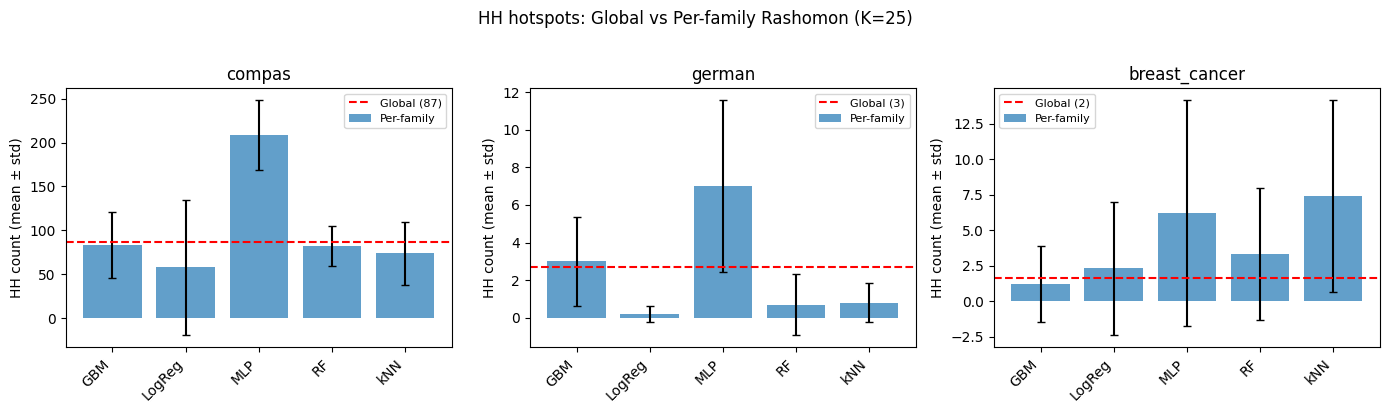

In [8]:
# Side-by-side comparison: Global vs Per-family (summed) HH counts per dataset
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, dataset in zip(axes, SUPPORTED_DATASETS):
    fam_sub = fam_agg[fam_agg["dataset"] == dataset]
    glob_sub = glob_agg[glob_agg["dataset"] == dataset]

    families = fam_sub["family"].values
    x = range(len(families))
    ax.bar(x, fam_sub["n_hh_mean"], yerr=fam_sub["n_hh_std"], capsize=3,
           alpha=0.7, label="Per-family")
    if not glob_sub.empty:
        ax.axhline(glob_sub["n_hh_mean"].values[0], color="red", ls="--",
                    label=f"Global ({glob_sub['n_hh_mean'].values[0]:.0f})")
    ax.set_xticks(list(x))
    ax.set_xticklabels(families, rotation=45, ha="right")
    ax.set_title(dataset)
    ax.set_ylabel("HH count (mean ± std)")
    ax.legend(fontsize=8)

fig.suptitle("HH hotspots: Global vs Per-family Rashomon (K=25)", y=1.02)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "_thesis_tables" / "global_vs_perfamily_hh.pdf",
            bbox_inches="tight")
plt.show()

In [9]:
# Save per-family summary CSV
per_fam_summary_path = RESULTS_DIR / "_thesis_tables" / "per_family_summary.csv"
fam_agg.to_csv(per_fam_summary_path, index=False)
print(f"Saved: {per_fam_summary_path}")

# Save global vs per-family comparison CSV
comparison_rows = []
for dataset in SUPPORTED_DATASETS:
    g = glob_agg[glob_agg["dataset"] == dataset].iloc[0]
    comparison_rows.append({
        "dataset": dataset,
        "selection": "global",
        "mean_variance": f"{g['mean_var_mean']:.6f} ± {g['mean_var_std']:.6f}",
        "moran_i": f"{g['moran_mean']:.4f} ± {g['moran_std']:.4f}",
        "n_hh": f"{g['n_hh_mean']:.1f} ± {g['n_hh_std']:.1f}",
    })
    f_sub = fam_agg[fam_agg["dataset"] == dataset]
    for _, row in f_sub.iterrows():
        comparison_rows.append({
            "dataset": dataset,
            "selection": f"per-family ({row['family']})",
            "mean_variance": f"{row['mean_var_mean']:.6f} ± {row['mean_var_std']:.6f}",
            "moran_i": f"{row['moran_mean']:.4f} ± {row['moran_std']:.4f}",
            "n_hh": f"{row['n_hh_mean']:.1f} ± {row['n_hh_std']:.1f}",
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RESULTS_DIR / "_thesis_tables" / "global_vs_perfamily_comparison.csv", index=False)
print(f"Saved: {RESULTS_DIR / '_thesis_tables' / 'global_vs_perfamily_comparison.csv'}")
display(comparison_df)

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\per_family_summary.csv
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\global_vs_perfamily_comparison.csv


,dataset,selection,mean_variance,moran_i,n_hh
0,compas,global,0.001308 ± 0.000306,0.1993 ± 0.0772,86.7 ± 55.0
1,compas,per-family (GBM),0.001245 ± 0.000290,0.2376 ± 0.0640,83.2 ± 37.7
2,compas,per-family (LogReg),0.000060 ± 0.000128,0.1720 ± 0.1979,57.7 ± 77.4
3,compas,per-family (MLP),0.001256 ± 0.000133,0.4216 ± 0.0486,208.5 ± 39.8
4,compas,per-family (RF),0.003239 ± 0.000355,0.1487 ± 0.0196,82.4 ± 22.9
5,compas,per-family (kNN),0.010692 ± 0.001397,0.0898 ± 0.0265,73.9 ± 36.0
6,german,global,0.005023 ± 0.002129,0.1042 ± 0.0397,2.7 ± 2.2
7,german,per-family (GBM),0.007108 ± 0.001192,0.1141 ± 0.0226,3.0 ± 2.4
8,german,per-family (LogReg),0.002121 ± 0.001283,0.0503 ± 0.0187,0.2 ± 0.4
9,german,per-family (MLP),0.009317 ± 0.002546,0.1676 ± 0.0429,7.0 ± 4.6


## Interpretation

- **mean_variance:** Average predictive variance across test points (Rashomon models). Higher values indicate more multiplicity.
- **moran_i:** Global Moran's I of pointwise variance; positive values indicate spatial clustering of high-variance points.
- **n_hh_mean:** Average number of high-high (HH) LISA hotspots per run.
- **frac_significant_moran:** Fraction of runs where observed Moran's I was significant vs the permutation null (p_empirical < 0.05).
- **null_mean / null_std:** Mean and spread of the null distribution of Moran's I (permuted predictions).